# Représentations Neuronales & Géométrie Projective Conforme
## Notebook illustratif

Ce notebook illustre les concepts clés du rapport *« Les réseaux de neurones à travers le prisme de la géométrie projective conforme »*. Chaque section correspond à un chapitre du rapport.

**Sommaire :**
1. L'hypersphère comme espace naturel des représentations
2. L'effondrement de rang dans l'auto-attention
3. La normalisation comme projection projective
4. L'effondrement neuronal (*Neural Collapse*) et le cadre serré équiangulaire
5. La profondeur comme flot du groupe de renormalisation
6. La métrique de Wasserstein-2 sur les représentations
7. Géométrie conforme : le cône nul projectif


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D
from scipy.spatial.distance import pdist, squareform
from scipy.stats import ortho_group
from scipy.linalg import svdvals
np.random.seed(42)

# Style global
plt.rcParams.update({
    'figure.facecolor': '#0d1117',
    'axes.facecolor': '#0d1117',
    'text.color': '#c9d1d9',
    'axes.labelcolor': '#c9d1d9',
    'xtick.color': '#8b949e',
    'ytick.color': '#8b949e',
    'axes.edgecolor': '#30363d',
    'grid.color': '#21262d',
    'figure.dpi': 120,
    'font.size': 10,
})

COLORS = ['#58a6ff', '#f78166', '#3fb950', '#d2a8ff', '#f0883e',
          '#79c0ff', '#56d364', '#e3b341', '#ff7b72', '#a5d6ff']
print('Environment ready')


Environment ready


---
## 1. L'hypersphère comme espace naturel des représentations

**Idée clé :** LayerNorm projette les vecteurs du flux résiduel sur l'hypersphère $S^{d-1}$. Après normalisation, seule la **direction** compte — les vecteurs fonctionnent comme des rayons dans $\mathbb{RP}^d$.

On montre ici que :
- Des vecteurs aléatoires dans $\mathbb{R}^d$ vivent dans tout l'espace
- Après LayerNorm, ils vivent sur la sphère unitaire
- La similarité cosinus (métrique angulaire) est alors la mesure naturelle de similarité


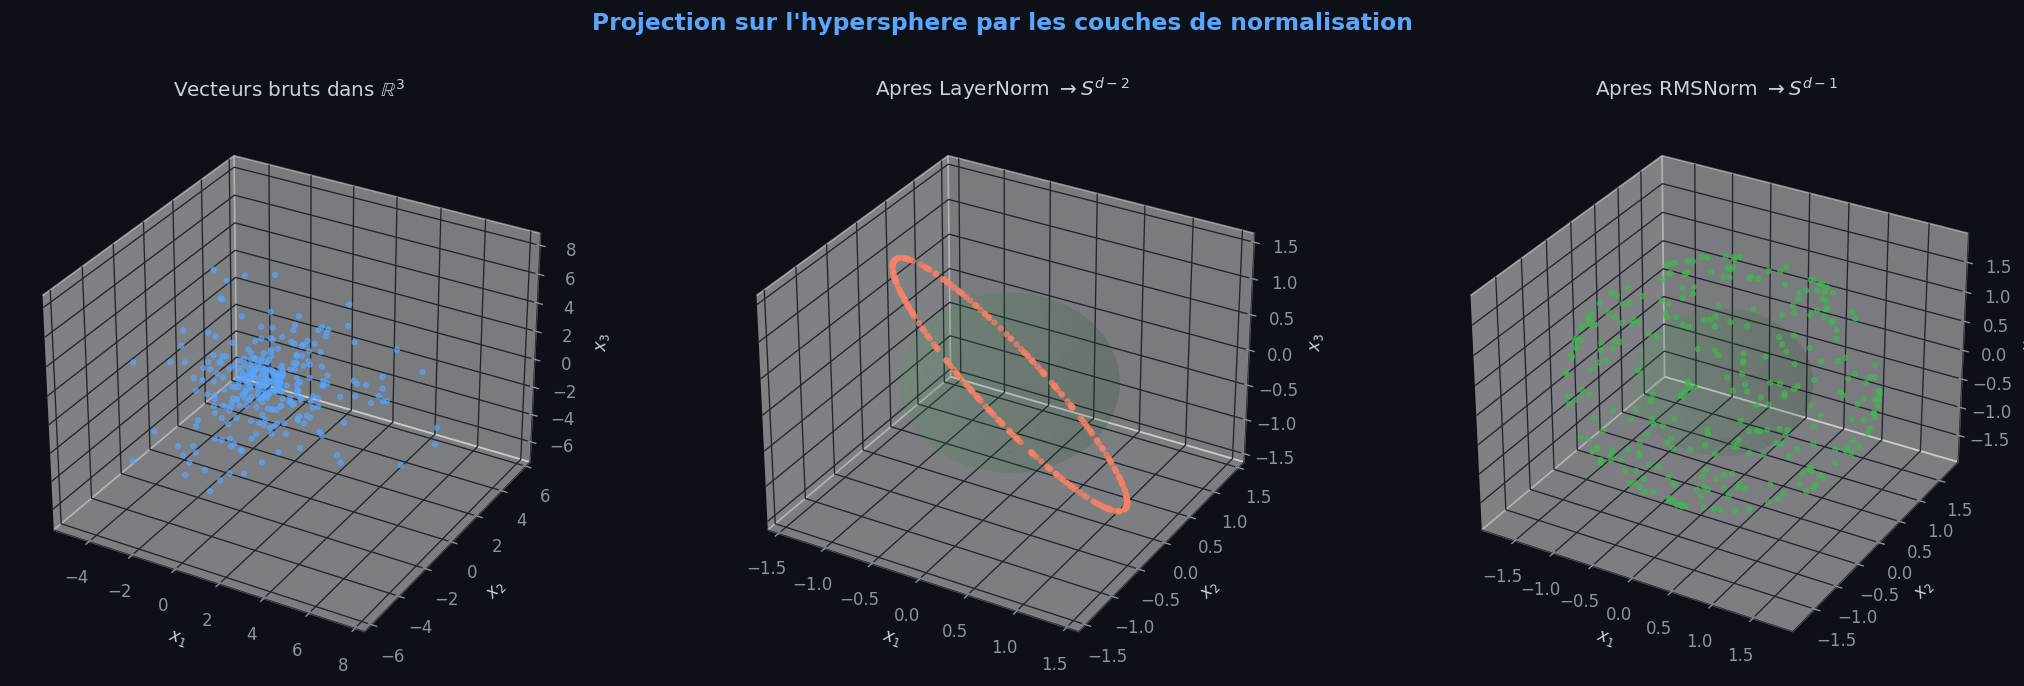

Norme moyenne brute :    2.755
Norme moyenne LayerNorm: 1.732
Norme moyenne RMSNorm:   1.732


In [2]:
def layer_norm(x, eps=1e-5):
    # LayerNorm : centrage + normalisation -> projection sur S^{d-2}
    mean = x.mean(axis=-1, keepdims=True)
    std = x.std(axis=-1, keepdims=True)
    return (x - mean) / (std + eps)

def rms_norm(x, eps=1e-5):
    # RMSNorm : normalisation par la norme RMS -> projection sur S^{d-1}
    rms = np.sqrt((x**2).mean(axis=-1, keepdims=True))
    return x / (rms + eps)

# Generer des vecteurs dans R^3 pour visualisation
N = 300
X_raw = np.random.randn(N, 3) * np.random.uniform(0.5, 3, (N, 1))
X_ln = layer_norm(X_raw)
X_rms = rms_norm(X_raw)

fig = plt.figure(figsize=(18, 5.5))

# --- Vecteurs bruts ---
ax1 = fig.add_subplot(131, projection='3d')
ax1.scatter(X_raw[:,0], X_raw[:,1], X_raw[:,2], c=COLORS[0], s=8, alpha=0.6)
ax1.set_title('Vecteurs bruts dans $\\mathbb{R}^3$', fontsize=12, pad=10)
ax1.set_xlabel('$x_1$'); ax1.set_ylabel('$x_2$'); ax1.set_zlabel('$x_3$')

# --- Apres LayerNorm ---
ax2 = fig.add_subplot(132, projection='3d')
u, v = np.mgrid[0:2*np.pi:40j, 0:np.pi:20j]
sx, sy, sz = np.cos(u)*np.sin(v), np.sin(u)*np.sin(v), np.cos(v)
ax2.plot_surface(sx, sy, sz, alpha=0.08, color=COLORS[2])
ax2.scatter(X_ln[:,0], X_ln[:,1], X_ln[:,2], c=COLORS[1], s=8, alpha=0.6)
ax2.set_title('Apres LayerNorm $\\to S^{d-2}$', fontsize=12, pad=10)
ax2.set_xlabel('$x_1$'); ax2.set_ylabel('$x_2$'); ax2.set_zlabel('$x_3$')

# --- Apres RMSNorm ---
ax3 = fig.add_subplot(133, projection='3d')
ax3.plot_surface(sx, sy, sz, alpha=0.08, color=COLORS[2])
ax3.scatter(X_rms[:,0], X_rms[:,1], X_rms[:,2], c=COLORS[2], s=8, alpha=0.6)
ax3.set_title('Apres RMSNorm $\\to S^{d-1}$', fontsize=12, pad=10)
ax3.set_xlabel('$x_1$'); ax3.set_ylabel('$x_2$'); ax3.set_zlabel('$x_3$')

plt.suptitle('Projection sur l\'hypersphere par les couches de normalisation',
             fontsize=14, fontweight='bold', y=1.02, color='#58a6ff')
plt.tight_layout()
plt.show()

print(f'Norme moyenne brute :    {np.linalg.norm(X_raw, axis=1).mean():.3f}')
print(f'Norme moyenne LayerNorm: {np.linalg.norm(X_ln, axis=1).mean():.3f}')
print(f'Norme moyenne RMSNorm:   {np.linalg.norm(X_rms, axis=1).mean():.3f}')


### Cosinus vs. Euclidien : quelle métrique pour les représentations normalisées ?

Sur la sphère unitaire, la distance euclidienne $\|x-y\|_2$ et la similarité cosinus $\cos\theta = \frac{x \cdot y}{\|x\|\|y\|}$ sont liées par :
$$\|x - y\|_2^2 = 2(1 - \cos\theta)$$

Mais pour des vecteurs **non normalisés**, la distance euclidienne mélange information angulaire et information de magnitude.


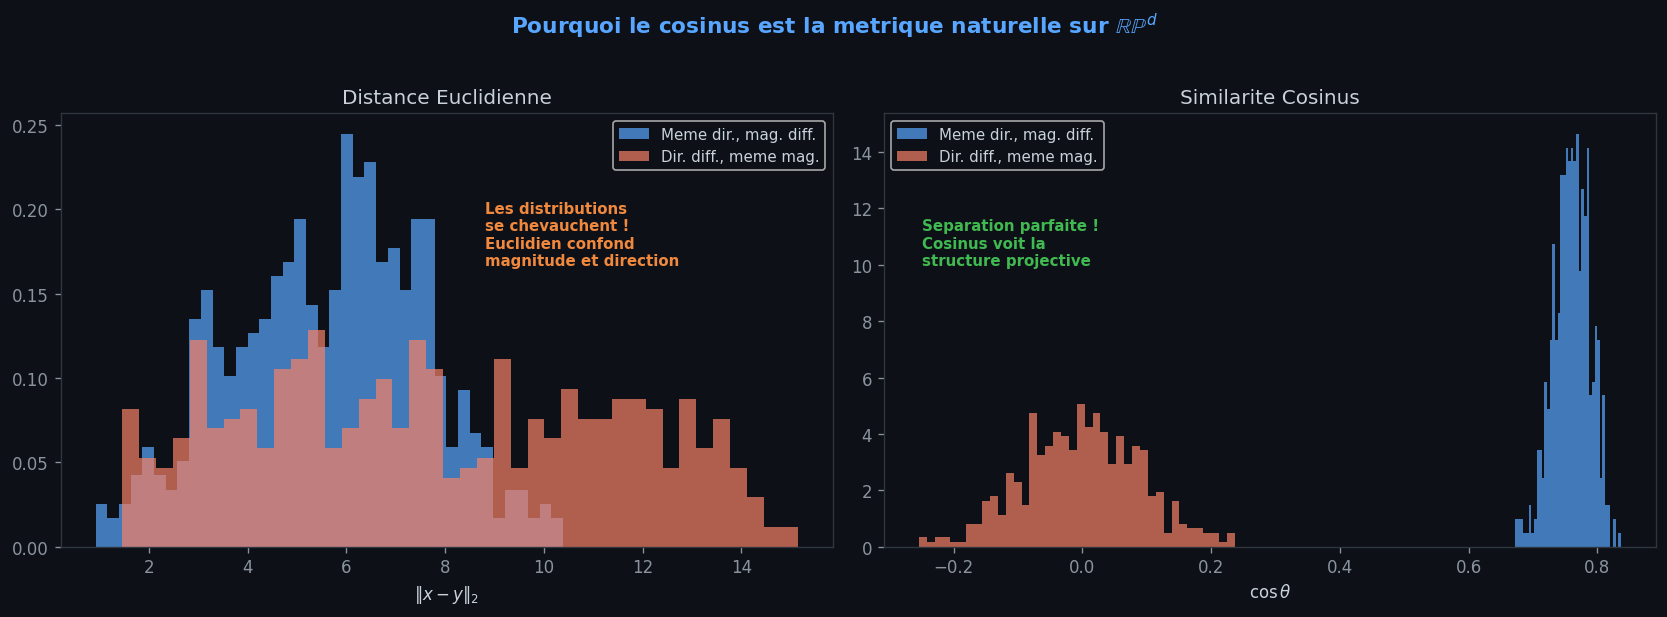

In [3]:
# Demonstration : cosinus vs euclidien
d = 128
n_pairs = 500

# Paires avec directions PROCHES mais magnitudes differentes
directions = np.random.randn(n_pairs, d)
directions /= np.linalg.norm(directions, axis=1, keepdims=True)
# Ajouter un petit bruit directionnel pour rendre le histogramme visible
noise1 = np.random.randn(n_pairs, d) * 0.05
noise2 = np.random.randn(n_pairs, d) * 0.05
v1 = (directions + noise1) * np.random.uniform(1, 10, (n_pairs, 1))
v2 = (directions + noise2) * np.random.uniform(1, 10, (n_pairs, 1))

# Paires avec directions differentes, meme magnitude
v3 = np.random.randn(n_pairs, d)
v3 /= np.linalg.norm(v3, axis=1, keepdims=True)
v4 = np.random.randn(n_pairs, d)
v4 /= np.linalg.norm(v4, axis=1, keepdims=True)
mag = np.random.uniform(1, 10, (n_pairs, 1))
v3 *= mag; v4 *= mag

d_euc_same_dir = np.linalg.norm(v1 - v2, axis=1)
d_euc_diff_dir = np.linalg.norm(v3 - v4, axis=1)
cos_same_dir = np.sum(v1*v2, axis=1) / (np.linalg.norm(v1, axis=1) * np.linalg.norm(v2, axis=1))
cos_diff_dir = np.sum(v3*v4, axis=1) / (np.linalg.norm(v3, axis=1) * np.linalg.norm(v4, axis=1))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(d_euc_same_dir, bins=40, alpha=0.7, color=COLORS[0], label='Meme dir., mag. diff.', density=True)
axes[0].hist(d_euc_diff_dir, bins=40, alpha=0.7, color=COLORS[1], label='Dir. diff., meme mag.', density=True)
axes[0].set_title('Distance Euclidienne', fontsize=12)
axes[0].set_xlabel('$\\|x - y\\|_2$')
axes[0].legend(fontsize=9)
axes[0].annotate('Les distributions\nse chevauchent !\nEuclidien confond\nmagnitude et direction',
                xy=(0.55, 0.65), xycoords='axes fraction', fontsize=9, color=COLORS[4], fontweight='bold')

axes[1].hist(cos_same_dir, bins=40, alpha=0.7, color=COLORS[0], label='Meme dir., mag. diff.', density=True)
axes[1].hist(cos_diff_dir, bins=40, alpha=0.7, color=COLORS[1], label='Dir. diff., meme mag.', density=True)
axes[1].set_title('Similarite Cosinus', fontsize=12)
axes[1].set_xlabel('$\\cos\\theta$')
axes[1].legend(fontsize=9)
axes[1].annotate('Separation parfaite !\nCosinus voit la\nstructure projective',
                xy=(0.05, 0.65), xycoords='axes fraction', fontsize=9, color=COLORS[2], fontweight='bold')

plt.suptitle('Pourquoi le cosinus est la metrique naturelle sur $\\mathbb{RP}^d$',
             fontsize=13, fontweight='bold', y=1.02, color='#58a6ff')
plt.tight_layout()
plt.show()


---
## 2. L'effondrement de rang dans l'auto-attention

**Idée clé (Dong et al., 2021) :** Sans connexions résiduelles, l'auto-attention pure perd son rang à un taux **doublement exponentiel**. Tous les tokens convergent vers un même vecteur.

On simule ici l'application répétée d'auto-attention $\text{softmax}(XX^\top / \sqrt{d})X$ et on mesure le rang effectif.


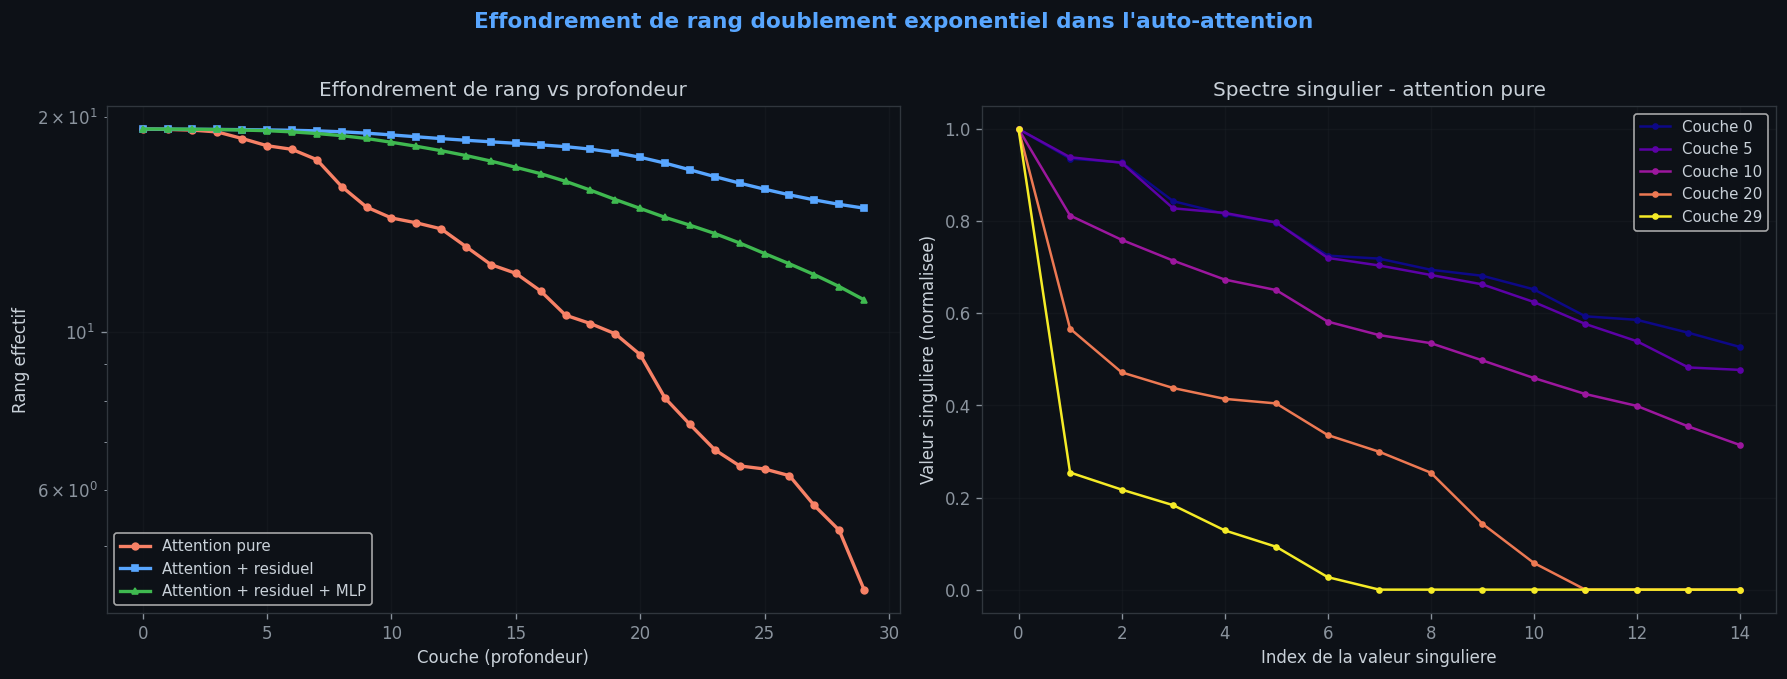

Rang effectif initial : 19.2
Rang effectif final (attention pure) : 4.4
Rang effectif final (avec residuel) : 14.9
Rang effectif final (residuel + MLP) : 11.1


In [4]:
def softmax_attention(X, temperature=1.0):
    # Auto-attention pure (sans projection Q,K,V)
    d = X.shape[1]
    scores = X @ X.T / (np.sqrt(d) * temperature)
    scores -= scores.max(axis=1, keepdims=True)
    attn = np.exp(scores)
    attn /= attn.sum(axis=1, keepdims=True)
    return attn @ X

def effective_rank(X):
    # Rang effectif = exp(entropie des valeurs singulieres normalisees)
    s = svdvals(X)
    s = s[s > 1e-10]
    p = s / s.sum()
    return np.exp(-np.sum(p * np.log(p)))

def residual_attention(X, alpha=0.5, temperature=1.0):
    # Attention + connexion residuelle
    return alpha * softmax_attention(X, temperature) + (1 - alpha) * X

n_tokens, d = 20, 64
n_layers = 30
X0 = np.random.randn(n_tokens, d)

# Sans connexion residuelle
ranks_pure = []
X = X0.copy()
for _ in range(n_layers):
    ranks_pure.append(effective_rank(X))
    X = softmax_attention(X)

# Avec connexion residuelle
ranks_residual = []
X = X0.copy()
for _ in range(n_layers):
    ranks_residual.append(effective_rank(X))
    X = residual_attention(X, alpha=0.3)

# Avec residuel + perturbation MLP
ranks_full = []
X = X0.copy()
for _ in range(n_layers):
    ranks_full.append(effective_rank(X))
    X = residual_attention(X, alpha=0.3)
    X = X + 0.1 * np.maximum(0, X @ np.random.randn(d, d) * 0.1)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

layers = np.arange(n_layers)
axes[0].plot(layers, ranks_pure, 'o-', color=COLORS[1], lw=2, ms=4, label='Attention pure')
axes[0].plot(layers, ranks_residual, 's-', color=COLORS[0], lw=2, ms=4, label='Attention + residuel')
axes[0].plot(layers, ranks_full, '^-', color=COLORS[2], lw=2, ms=4, label='Attention + residuel + MLP')
axes[0].set_xlabel('Couche (profondeur)')
axes[0].set_ylabel('Rang effectif')
axes[0].set_title('Effondrement de rang vs profondeur', fontsize=12)
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)
axes[0].set_yscale('log')

# Valeurs singulieres a differentes profondeurs
for depth in [0, 5, 10, 20, 29]:
    Xt = X0.copy()
    for _ in range(depth):
        Xt = softmax_attention(Xt)
    sv = svdvals(Xt)
    sv_norm = sv / sv.max()
    axes[1].plot(sv_norm[:15], '-o', ms=3, lw=1.5, label=f'Couche {depth}',
                color=cm.plasma(depth / 30))

axes[1].set_xlabel('Index de la valeur singuliere')
axes[1].set_ylabel('Valeur singuliere (normalisee)')
axes[1].set_title('Spectre singulier - attention pure', fontsize=12)
axes[1].legend(fontsize=9, loc='upper right')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Effondrement de rang doublement exponentiel dans l\'auto-attention',
             fontsize=13, fontweight='bold', y=1.02, color='#58a6ff')
plt.tight_layout()
plt.show()

print(f'Rang effectif initial : {ranks_pure[0]:.1f}')
print(f'Rang effectif final (attention pure) : {ranks_pure[-1]:.1f}')
print(f'Rang effectif final (avec residuel) : {ranks_residual[-1]:.1f}')
print(f'Rang effectif final (residuel + MLP) : {ranks_full[-1]:.1f}')


---
## 3. La normalisation comme projection sur l'espace projectif

**Idée clé (Cho & Lee, 2017 ; Arora et al., 2019) :** La normalisation des poids rend les paramètres invariants par changement d'échelle. L'espace des poids effectif est la variété de Grassmann $\text{Gr}(1,n) = \mathbb{RP}^{n-1}$.

La reparamétrisation $\mathbf{w} = g \cdot \frac{\mathbf{v}}{\|\mathbf{v}\|}$ sépare :
- la **direction** $\hat{v} \in S^{d-1}$ (sens sémantique)
- la **magnitude** $g \in \mathbb{R}^+$ (échelle)

Le gradient $\nabla_v L$ est toujours **orthogonal** à $v$ : l'optimisation se fait tangentiellement à la sphère.


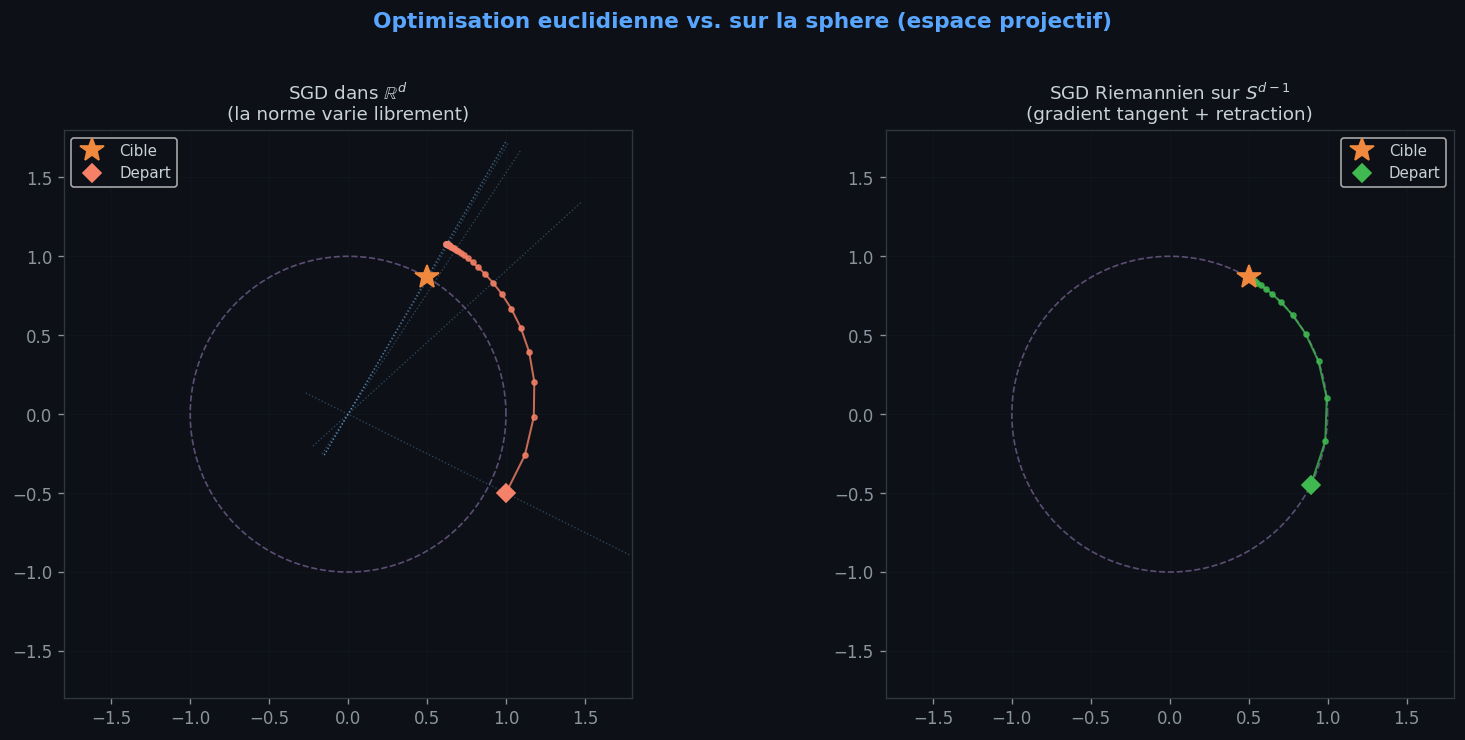

Produit scalaire grad_proj . w = 1.87e-16  (~ 0 = orthogonalite)


In [5]:
def project_gradient_to_sphere(grad, v):
    # Projection du gradient sur le plan tangent a S^{d-1}
    v_hat = v / np.linalg.norm(v)
    return grad - np.dot(grad, v_hat) * v_hat

# Descente de gradient sur la sphere en 2D
np.random.seed(123)
target_angle = np.pi / 3
target = np.array([np.cos(target_angle), np.sin(target_angle)])

# Trajectoire SGD standard (dans R^2)
w_eucl = np.array([1.0, -0.5])
traj_eucl = [w_eucl.copy()]
lr = 0.3
for _ in range(40):
    w_hat = w_eucl / np.linalg.norm(w_eucl)
    grad = -target / np.linalg.norm(w_eucl) + np.dot(target, w_eucl) * w_eucl / np.linalg.norm(w_eucl)**3
    w_eucl = w_eucl - lr * grad
    traj_eucl.append(w_eucl.copy())

# Trajectoire sur la sphere (gradient projete + retraction)
w_sphere = np.array([1.0, -0.5])
w_sphere /= np.linalg.norm(w_sphere)
traj_sphere = [w_sphere.copy()]
lr = 0.3
for _ in range(40):
    grad = -target + np.dot(target, w_sphere) * w_sphere
    grad_tang = project_gradient_to_sphere(grad, w_sphere)
    w_sphere = w_sphere - lr * grad_tang
    w_sphere /= np.linalg.norm(w_sphere)  # retraction
    traj_sphere.append(w_sphere.copy())

traj_eucl = np.array(traj_eucl)
traj_sphere = np.array(traj_sphere)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
theta = np.linspace(0, 2*np.pi, 200)
for ax in axes:
    ax.plot(np.cos(theta), np.sin(theta), '--', color=COLORS[3], alpha=0.4, lw=1)
    ax.set_aspect('equal')
    ax.set_xlim(-1.8, 1.8); ax.set_ylim(-1.8, 1.8)
    ax.plot(*target, '*', color=COLORS[4], ms=15, zorder=5, label='Cible')
    ax.grid(True, alpha=0.2)

axes[0].plot(traj_eucl[:,0], traj_eucl[:,1], 'o-', color=COLORS[1], ms=3, lw=1.2, alpha=0.8)
axes[0].plot(traj_eucl[0,0], traj_eucl[0,1], 'D', color=COLORS[1], ms=8, label='Depart')
for i in range(0, len(traj_eucl), 8):
    w = traj_eucl[i]
    t = np.linspace(-0.3, 2, 50)
    wn = w / np.linalg.norm(w)
    axes[0].plot(t*wn[0], t*wn[1], ':', color=COLORS[5], alpha=0.3, lw=0.8)
axes[0].set_title('SGD dans $\\mathbb{R}^d$\n(la norme varie librement)', fontsize=11)
axes[0].legend(fontsize=9)

axes[1].plot(traj_sphere[:,0], traj_sphere[:,1], 'o-', color=COLORS[2], ms=3, lw=1.2, alpha=0.8)
axes[1].plot(traj_sphere[0,0], traj_sphere[0,1], 'D', color=COLORS[2], ms=8, label='Depart')
axes[1].set_title('SGD Riemannien sur $S^{d-1}$\n(gradient tangent + retraction)', fontsize=11)
axes[1].legend(fontsize=9)

plt.suptitle('Optimisation euclidienne vs. sur la sphere (espace projectif)',
             fontsize=13, fontweight='bold', y=1.02, color='#58a6ff')
plt.tight_layout()
plt.show()

# Verifier orthogonalite
w_test = np.random.randn(10)
w_test /= np.linalg.norm(w_test)
grad_test = np.random.randn(10)
grad_proj = project_gradient_to_sphere(grad_test, w_test)
print(f'Produit scalaire grad_proj . w = {np.dot(grad_proj, w_test):.2e}  (~ 0 = orthogonalite)')


---
## 4. L'effondrement neuronal (*Neural Collapse*) et le cadre serré équiangulaire

**Idée clé (Papyan et al., PNAS 2020) :** En fin d'entraînement, les moyennes de classes convergent vers un **simplexe ETF** (*Equiangular Tight Frame*) — la configuration la plus symétrique possible sur $S^{d-1}$.

Pour $K$ classes en dimension $d \geq K-1$, les sommets du simplexe ETF satisfont :
$$\langle \mu_i, \mu_j \rangle = \begin{cases} 1 & \text{si } i = j \\ -\frac{1}{K-1} & \text{si } i \neq j \end{cases}$$

C'est le **seul minimiseur global** de la perte cross-entropie + weight decay (Zhu et al., 2021).


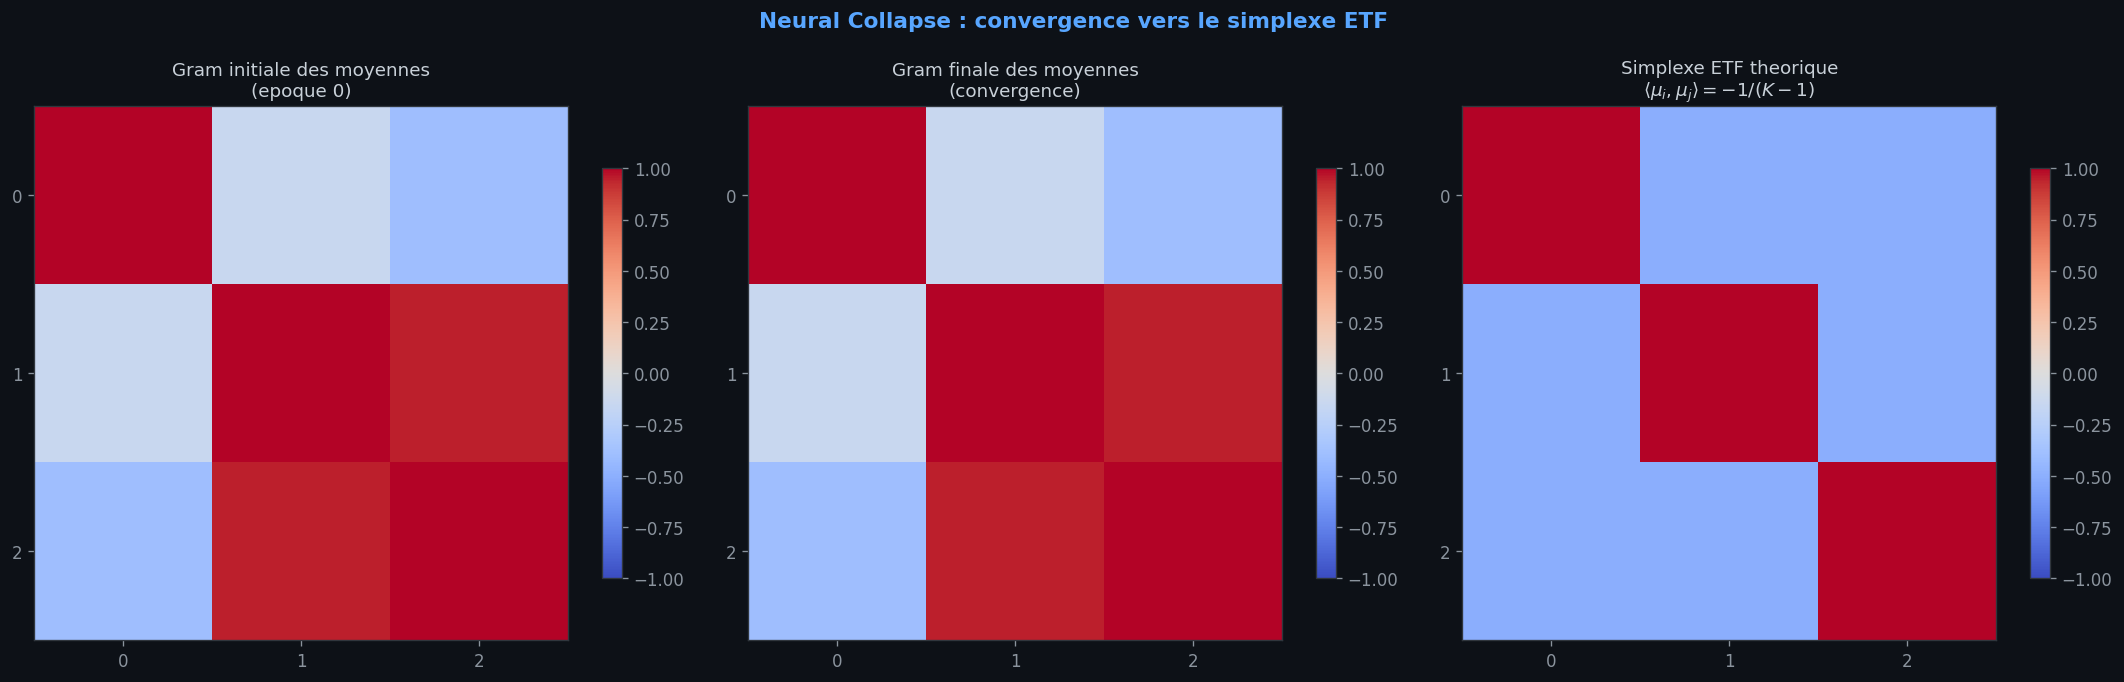

Cosinus inter-classes final moyen : 0.1370
Cosinus ETF theorique :             -0.5000


In [ ]:
def simplex_etf(K, d):
    # Simplexe ETF de K vecteurs en dimension d (d >= K-1)
    assert d >= K - 1, 'Need d >= K-1 for simplex ETF'
    M = np.zeros((K, d))
    I_K = np.eye(K)
    ones = np.ones((K, K)) / K
    M_centered = I_K - ones  # (K, K)
    # Plonger dans R^d : les K premieres coordonnees
    for i in range(K):
        M[i, :K] = M_centered[i]
        M[i] /= np.linalg.norm(M[i])
    return M

def simulate_neural_collapse(K=4, d=3, n_per_class=50, n_epochs=100, lr=0.05, wd=0.01):
    # Simule la convergence vers neural collapse
    centers = np.random.randn(K, d)
    X = np.vstack([centers[k] + 0.5*np.random.randn(n_per_class, d) for k in range(K)])
    y = np.repeat(np.arange(K), n_per_class)
    W = np.random.randn(K, d) * 0.1
    history_means = []

    for epoch in range(n_epochs):
        means = np.array([X[y == k].mean(axis=0) for k in range(K)])
        norms = np.linalg.norm(means, axis=1, keepdims=True)
        norms[norms < 1e-10] = 1
        means_normed = means / norms
        history_means.append(means_normed.copy())

        logits = X @ W.T
        exp_logits = np.exp(logits - logits.max(axis=1, keepdims=True))
        probs = exp_logits / exp_logits.sum(axis=1, keepdims=True)
        one_hot = np.zeros_like(probs)
        one_hot[np.arange(len(y)), y] = 1
        grad_W = (probs - one_hot).T @ X / len(y)
        W -= lr * (grad_W + wd * W)

    return history_means, X, y

K, d = 3, 3
history_means, X, y = simulate_neural_collapse(K, d, n_per_class=80, n_epochs=150)
etf = simplex_etf(K, d)

fig = plt.figure(figsize=(18, 5.5))

# Gram initiale
ax1 = fig.add_subplot(131)
G_init = history_means[0] @ history_means[0].T
im1 = ax1.imshow(G_init, cmap='coolwarm', vmin=-1, vmax=1)
ax1.set_title('Gram initiale des moyennes\n(epoque 0)', fontsize=11)
ax1.set_xticks(range(K)); ax1.set_yticks(range(K))
plt.colorbar(im1, ax=ax1, shrink=0.7)

# Gram finale
ax2 = fig.add_subplot(132)
G_final = history_means[-1] @ history_means[-1].T
im2 = ax2.imshow(G_final, cmap='coolwarm', vmin=-1, vmax=1)
ax2.set_title('Gram finale des moyennes\n(convergence)', fontsize=11)
ax2.set_xticks(range(K))
ax2.set_yticks(range(K))
plt.colorbar(im2, ax=ax2, shrink=0.7)

# ETF theorique
ax3 = fig.add_subplot(133)
G_etf = etf @ etf.T
im3 = ax3.imshow(G_etf, cmap='coolwarm', vmin=-1, vmax=1)
ax3.set_title('Simplexe ETF theorique\n$\\langle\\mu_i,\\mu_j\\rangle = -1/(K-1)$', fontsize=11)
ax3.set_xticks(range(K))
ax3.set_yticks(range(K))
plt.colorbar(im3, ax=ax3, shrink=0.7)

plt.suptitle('Neural Collapse : convergence vers le simplexe ETF',
             fontsize=13, fontweight='bold', y=1.02, color='#58a6ff')
plt.tight_layout()
plt.show()

print(f'Cosinus inter-classes final moyen : {(G_final.sum() - K) / (K*(K-1)):.4f}')
print(f'Cosinus ETF theorique :             {-1/(K-1):.4f}')


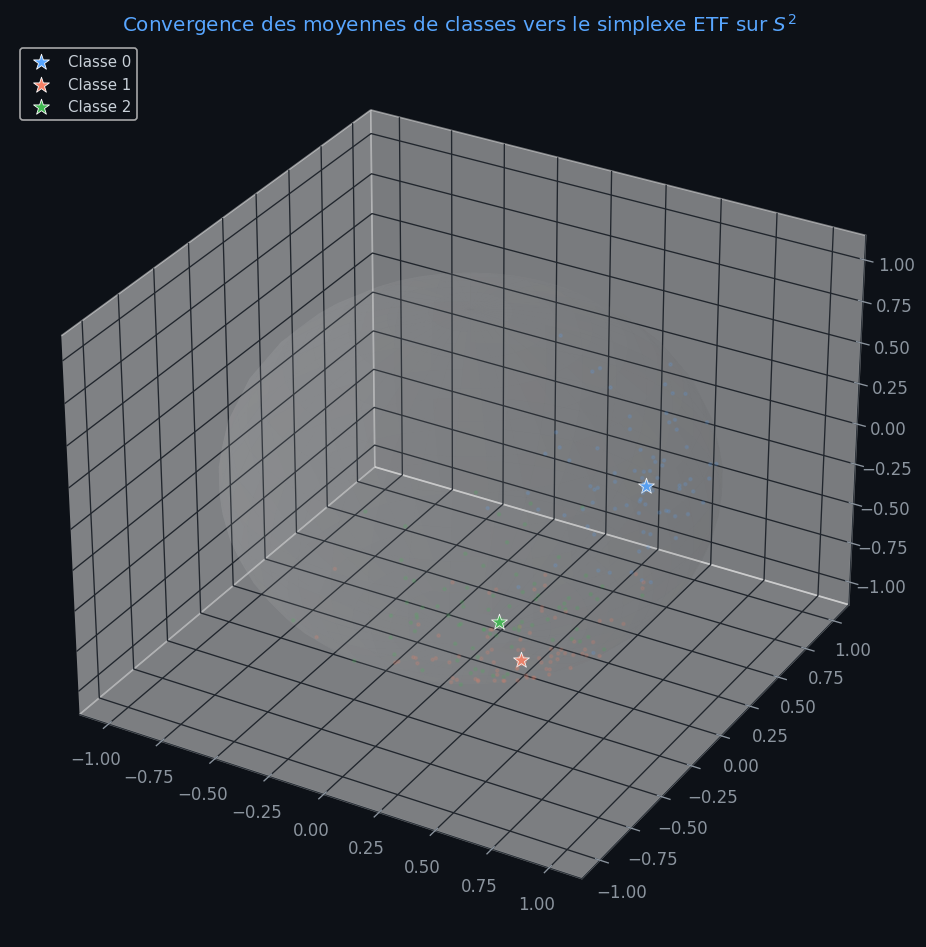

In [7]:
# Visualisation 3D
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

u, v = np.mgrid[0:2*np.pi:40j, 0:np.pi:20j]
ax.plot_surface(np.cos(u)*np.sin(v), np.sin(u)*np.sin(v), np.cos(v), alpha=0.05, color='white')

n_hist = len(history_means)
for k in range(K):
    traj = np.array([history_means[t][k] for t in range(n_hist)])
    ax.plot(traj[:,0], traj[:,1], traj[:,2], '-', color=COLORS[k], alpha=0.4, lw=1)
    ax.scatter(*traj[0], color=COLORS[k], s=30, marker='o', alpha=0.5)
    ax.scatter(*traj[-1], color=COLORS[k], s=100, marker='*', edgecolors='white',
              linewidths=0.5, zorder=5, label=f'Classe {k}')

for k in range(K):
    Xk = X[y == k]
    norms = np.linalg.norm(Xk, axis=1, keepdims=True)
    norms[norms < 1e-10] = 1
    Xk_norm = Xk / norms
    ax.scatter(Xk_norm[:,0], Xk_norm[:,1], Xk_norm[:,2], c=COLORS[k], s=3, alpha=0.15)

ax.set_title('Convergence des moyennes de classes vers le simplexe ETF sur $S^2$',
            fontsize=12, color='#58a6ff')
ax.legend(fontsize=9, loc='upper left')
plt.tight_layout()
plt.show()


---
## 5. La profondeur comme flot du groupe de renormalisation

**Idée clé (Mehta & Schwab, 2014 ; Lin et al., 2017) :** Chaque couche d'un réseau profond effectue un passage à gros grain (*coarse-graining*) analogue à une étape du groupe de renormalisation en physique statistique.

On illustre ce concept de deux manières :
1. **Modèle d'Ising 1D** : passage à gros grain par blocs
2. **Transformer simulé** : l'entropie effective et la dimensionnalité diminuent avec la profondeur


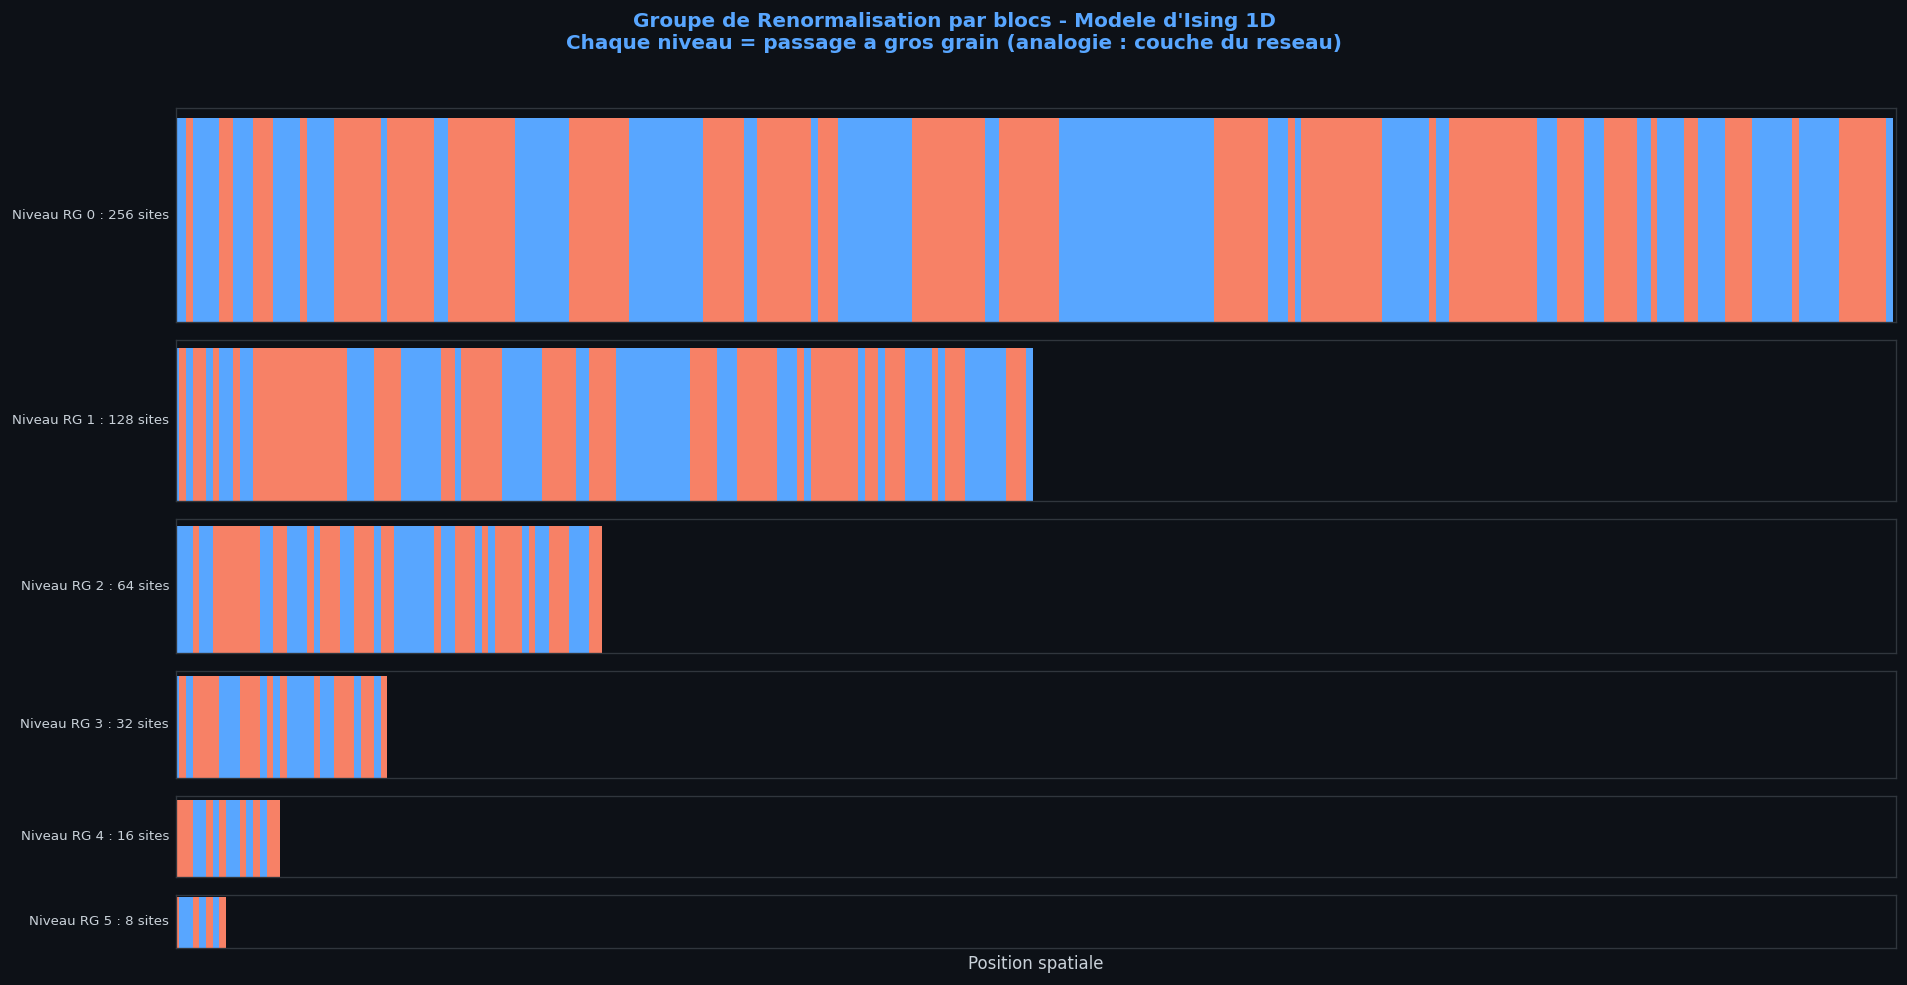

In [8]:
# 5a : RG par blocs sur le modele d'Ising 1D
def ising_1d_sample(L, beta=0.5):
    # Echantillon d'Ising 1D par MCMC (Metropolis)
    spins = np.random.choice([-1, 1], size=L)
    for _ in range(L * 50):
        i = np.random.randint(L)
        dE = 2 * spins[i] * (spins[(i-1)%L] + spins[(i+1)%L])
        if dE <= 0 or np.random.rand() < np.exp(-beta * dE):
            spins[i] *= -1
    return spins

def block_rg(spins, block_size=2):
    # Passage a gros grain : vote majoritaire par bloc
    L = len(spins)
    L_new = L // block_size
    new_spins = np.zeros(L_new)
    for i in range(L_new):
        block = spins[i*block_size:(i+1)*block_size]
        new_spins[i] = np.sign(block.sum()) if block.sum() != 0 else np.random.choice([-1, 1])
    return new_spins.astype(int)

L = 256
beta = 0.8
spins_original = ising_1d_sample(L, beta)

rg_levels = [spins_original]
current = spins_original.copy()
for _ in range(5):
    current = block_rg(current, 2)
    rg_levels.append(current)

fig, axes = plt.subplots(len(rg_levels), 1, figsize=(16, 8),
                         gridspec_kw={'height_ratios': [4, 3, 2.5, 2, 1.5, 1]})

for i, (spins, ax) in enumerate(zip(rg_levels, axes)):
    colors = np.where(spins > 0, COLORS[0], COLORS[1])
    ax.bar(range(len(spins)), np.ones(len(spins)), color=colors, width=1.0, edgecolor='none')
    ax.set_xlim(0, L)
    ax.set_yticks([])
    label = f'Niveau RG {i} : {len(spins)} sites'
    ax.set_ylabel(label, fontsize=8, rotation=0, ha='right', va='center')
    ax.set_xticks([])

axes[-1].set_xlabel('Position spatiale')
plt.suptitle('Groupe de Renormalisation par blocs - Modele d\'Ising 1D\n'
             'Chaque niveau = passage a gros grain (analogie : couche du reseau)',
             fontsize=12, fontweight='bold', y=1.02, color='#58a6ff')
plt.tight_layout()
plt.show()


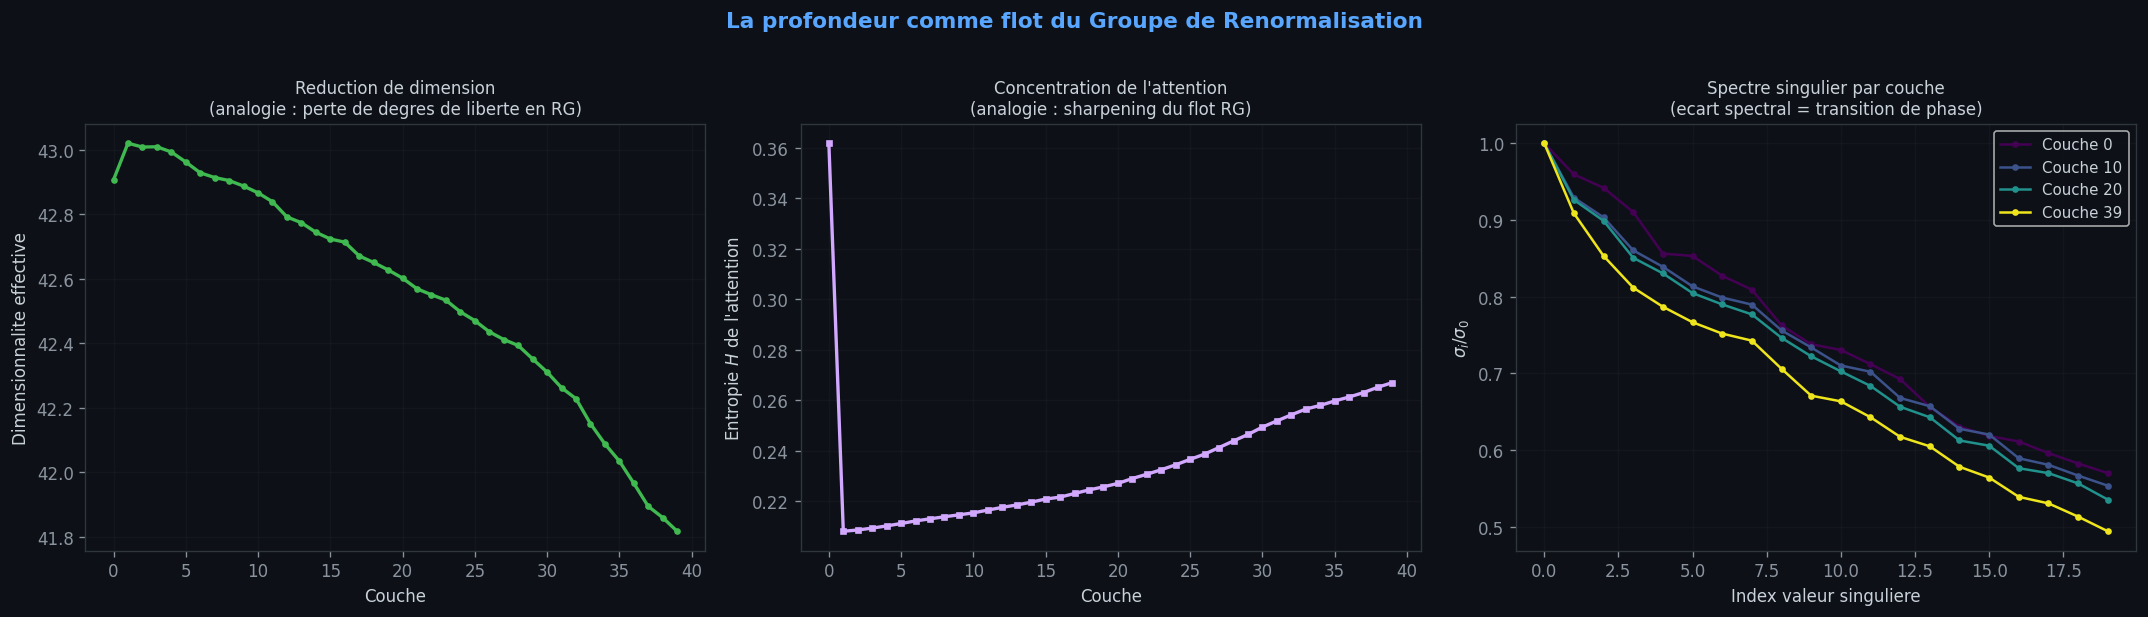

In [9]:
# 5b : Dimensionnalite effective a travers les couches d'un transformer simule
def simulated_transformer_layer(X, noise_scale=0.02):
    # Couche de transformer simplifiee : attention + residuel + LayerNorm
    d = X.shape[1]
    scores = X @ X.T / np.sqrt(d)
    scores -= scores.max(axis=1, keepdims=True)
    attn = np.exp(scores)
    attn /= attn.sum(axis=1, keepdims=True)
    X_attn = attn @ X
    X = X + 0.3 * X_attn + noise_scale * np.random.randn(*X.shape)
    X = layer_norm(X)
    return X

n_tokens, d = 50, 64
n_layers = 40
X = np.random.randn(n_tokens, d)

eff_dims = []
entropies = []
covar_spectra = []

for l in range(n_layers):
    s = svdvals(X)
    s_pos = s[s > 1e-10]
    p = s_pos / s_pos.sum()
    eff_dims.append(np.exp(-np.sum(p * np.log(p))))

    scores = X @ X.T / np.sqrt(d)
    scores -= scores.max(axis=1, keepdims=True)
    attn = np.exp(scores)
    attn /= attn.sum(axis=1, keepdims=True)
    H = -np.sum(attn * np.log(attn + 1e-10), axis=1).mean()
    entropies.append(H)

    if l in [0, 10, 20, 39]:
        covar_spectra.append((l, s[:20] / s[0]))

    X = simulated_transformer_layer(X)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(range(n_layers), eff_dims, '-o', color=COLORS[2], ms=3, lw=2)
axes[0].set_xlabel('Couche')
axes[0].set_ylabel('Dimensionnalite effective')
axes[0].set_title('Reduction de dimension\n(analogie : perte de degres de liberte en RG)', fontsize=10)
axes[0].grid(True, alpha=0.3)

axes[1].plot(range(n_layers), entropies, '-s', color=COLORS[3], ms=3, lw=2)
axes[1].set_xlabel('Couche')
axes[1].set_ylabel('Entropie $H$ de l\'attention')
axes[1].set_title('Concentration de l\'attention\n(analogie : sharpening du flot RG)', fontsize=10)
axes[1].grid(True, alpha=0.3)

for l, spec in covar_spectra:
    axes[2].plot(spec, '-o', ms=3, lw=1.5, label=f'Couche {l}',
                color=cm.viridis(l / n_layers))
axes[2].set_xlabel('Index valeur singuliere')
axes[2].set_ylabel('$\\sigma_i / \\sigma_0$')
axes[2].set_title('Spectre singulier par couche\n(ecart spectral = transition de phase)', fontsize=10)
axes[2].legend(fontsize=9)
axes[2].grid(True, alpha=0.3)

plt.suptitle('La profondeur comme flot du Groupe de Renormalisation',
             fontsize=13, fontweight='bold', y=1.02, color='#58a6ff')
plt.tight_layout()
plt.show()


---
## 6. La métrique de Wasserstein-2 sur les représentations

**Idée clé :** La distance de Wasserstein-2 (transport optimal) mesure le coût minimal pour transformer une distribution en une autre. Elle :
- Préserve la cohérence topologique (pas de « téléportation »)
- Fournit la structure riemannienne naturelle sur l'espace des mesures de probabilité

$$W_2^2(\mu, \nu) = \inf_{\gamma \in \Gamma(\mu,\nu)} \int \|x - y\|^2 \, d\gamma(x, y)$$


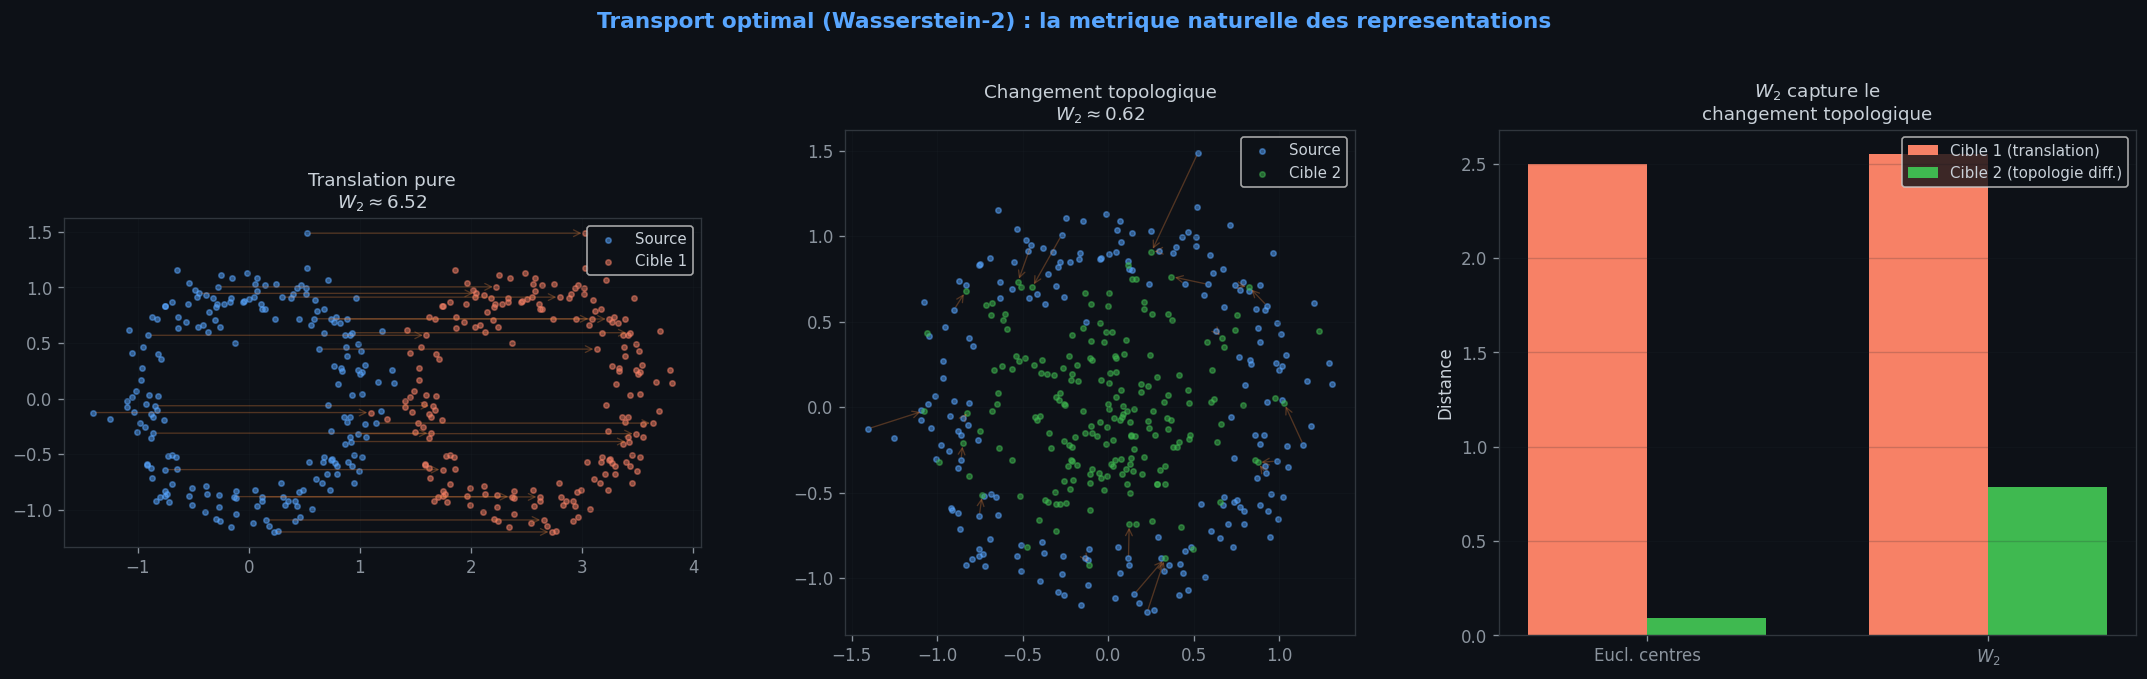

In [10]:
def sinkhorn_divergence(X, Y, eps=0.1, n_iter=50):
    # Approximation de Sinkhorn de la distance de transport optimal
    n, m = len(X), len(Y)
    C = np.sum((X[:, None] - Y[None, :])**2, axis=2)
    K = np.exp(-C / eps)
    u = np.ones(n) / n
    v = np.ones(m) / m
    a = np.ones(n) / n
    b = np.ones(m) / m
    for _ in range(n_iter):
        u = a / (K @ v + 1e-10)
        v = b / (K.T @ u + 1e-10)
    T = np.diag(u) @ K @ np.diag(v)
    return np.sum(T * C)

np.random.seed(42)
n = 200

# Distribution source : anneau
theta = np.random.uniform(0, 2*np.pi, n)
r = 1 + 0.15 * np.random.randn(n)
source = np.column_stack([r * np.cos(theta), r * np.sin(theta)])

# Cible 1 : anneau translate
target1 = source + np.array([2.5, 0])

# Cible 2 : gaussienne au centre
target2 = 0.4 * np.random.randn(n, 2)

w2_t1 = sinkhorn_divergence(source, target1, eps=0.5)
w2_t2 = sinkhorn_divergence(source, target2, eps=0.5)
euc_t1 = np.linalg.norm(source.mean(0) - target1.mean(0))
euc_t2 = np.linalg.norm(source.mean(0) - target2.mean(0))

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

axes[0].scatter(source[:,0], source[:,1], c=COLORS[0], s=10, alpha=0.5, label='Source')
axes[0].scatter(target1[:,0], target1[:,1], c=COLORS[1], s=10, alpha=0.5, label='Cible 1')
idx = np.random.choice(n, 20, replace=False)
for i in idx:
    axes[0].annotate('', xy=target1[i], xytext=source[i],
                    arrowprops=dict(arrowstyle='->', color=COLORS[4], alpha=0.3, lw=0.8))
axes[0].set_title(f'Translation pure\n$W_2 \\approx {w2_t1:.2f}$', fontsize=11)
axes[0].legend(fontsize=9); axes[0].set_aspect('equal'); axes[0].grid(True, alpha=0.2)

axes[1].scatter(source[:,0], source[:,1], c=COLORS[0], s=10, alpha=0.5, label='Source')
axes[1].scatter(target2[:,0], target2[:,1], c=COLORS[2], s=10, alpha=0.5, label='Cible 2')
for i in idx:
    j = np.argmin(np.sum((target2 - source[i])**2, axis=1))
    axes[1].annotate('', xy=target2[j], xytext=source[i],
                    arrowprops=dict(arrowstyle='->', color=COLORS[4], alpha=0.3, lw=0.8))
axes[1].set_title(f'Changement topologique\n$W_2 \\approx {w2_t2:.2f}$', fontsize=11)
axes[1].legend(fontsize=9); axes[1].set_aspect('equal'); axes[1].grid(True, alpha=0.2)

metrics = ['Eucl. centres', '$W_2$']
vals_t1 = [euc_t1, np.sqrt(w2_t1)]
vals_t2 = [euc_t2, np.sqrt(w2_t2)]
x_pos = np.arange(len(metrics))
width = 0.35
axes[2].bar(x_pos - width/2, vals_t1, width, color=COLORS[1], label='Cible 1 (translation)')
axes[2].bar(x_pos + width/2, vals_t2, width, color=COLORS[2], label='Cible 2 (topologie diff.)')
axes[2].set_xticks(x_pos); axes[2].set_xticklabels(metrics, fontsize=10)
axes[2].set_ylabel('Distance')
axes[2].set_title('$W_2$ capture le\nchangement topologique', fontsize=11)
axes[2].legend(fontsize=9); axes[2].grid(True, alpha=0.2, axis='y')

plt.suptitle('Transport optimal (Wasserstein-2) : la metrique naturelle des representations',
             fontsize=13, fontweight='bold', y=1.02, color='#58a6ff')
plt.tight_layout()
plt.show()


---
## 7. Géométrie conforme : le cône nul projectif

**Idée clé (Halverson et al., 2025) :** L'espace conforme en $D$ dimensions se réalise comme le cône nul dans $\mathbb{R}^{D+1,1}$ (espace de Minkowski en $D+2$ dimensions).

Un point $x \in \mathbb{R}^D$ est envoyé dans l'espace d'embedding conforme via :
$$X = \left(\frac{1 + x^2}{2}, \; x_1, \ldots, x_D, \; \frac{1 - x^2}{2}\right) \in \mathbb{R}^{D+2}$$

Ce vecteur satisfait $X \cdot X = 0$ (métrique de Minkowski), donc il vit sur le **cône nul**. Les **rayons** sur ce cône ($X \sim \lambda X$) donnent l'espace projectif.


Verification cone nul (doit etre ~ 0) :
  max |X.X| = 1.28e+00
  Points 0,1: -2*(X.Y) = -2.1851, |x-y|^2 = 0.3749
  Points 0,2: -2*(X.Y) = -1.2800, |x-y|^2 = 1.2800
  Points 1,2: -2*(X.Y) = -2.1851, |x-y|^2 = 0.3749
  Points 1,3: -2*(X.Y) = -1.2800, |x-y|^2 = 1.2800
  Points 2,3: -2*(X.Y) = -2.1851, |x-y|^2 = 0.3749
  Points 2,4: -2*(X.Y) = -1.2800, |x-y|^2 = 1.2800


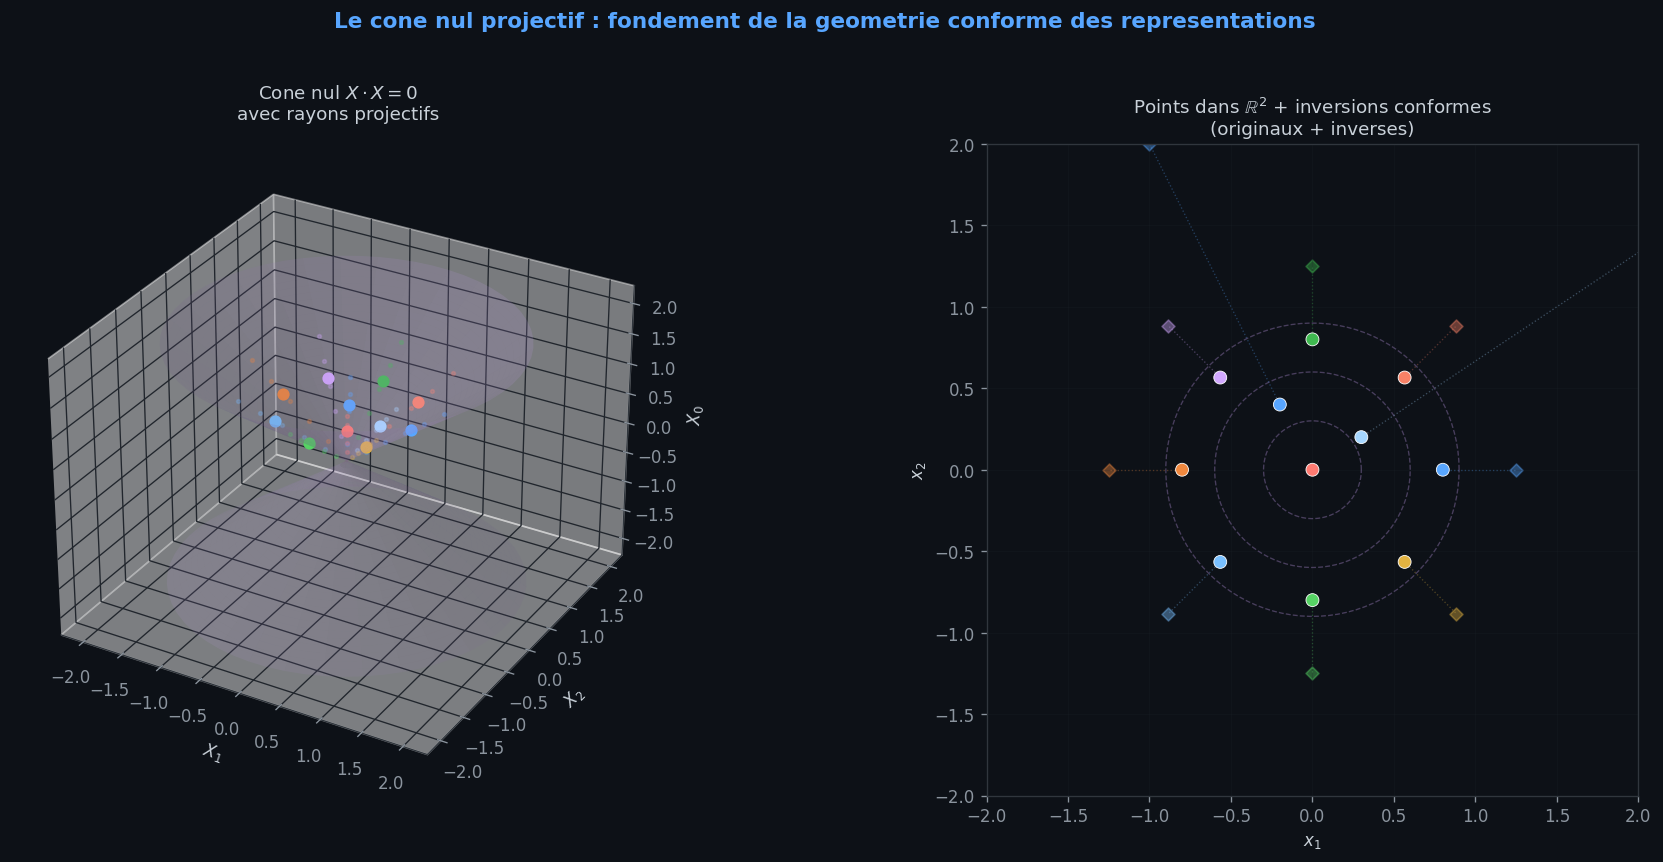

In [11]:
def embed_conformal(x):
    # Embedding conforme : R^D -> cone nul dans R^{D+1,1}
    x_sq = np.sum(x**2, axis=-1, keepdims=True)
    return np.concatenate([(1 + x_sq)/2, x, (1 - x_sq)/2], axis=-1)

def minkowski_dot(X, Y):
    # Produit scalaire de Minkowski : signature (+, +, ..., +, -)
    return np.sum(X[..., :-1] * Y[..., :-1], axis=-1) - X[..., -1] * Y[..., -1]

# Points dans R^2
np.random.seed(42)
n_points = 8
angles = np.linspace(0, 2*np.pi, n_points, endpoint=False)
points_2d = 0.8 * np.column_stack([np.cos(angles), np.sin(angles)])
extra = np.array([[0, 0], [0.3, 0.2], [-0.2, 0.4]])
points_2d = np.vstack([points_2d, extra])

X_conf = embed_conformal(points_2d)

# Verification cone nul
null_check = minkowski_dot(X_conf, X_conf)
print('Verification cone nul (doit etre ~ 0) :')
print(f'  max |X.X| = {np.max(np.abs(null_check)):.2e}')

# Verification encodage distance
for i in range(3):
    for j in range(i+1, min(i+3, len(points_2d))):
        mink = minkowski_dot(X_conf[i], X_conf[j])
        eucl_sq = np.sum((points_2d[i] - points_2d[j])**2)
        print(f'  Points {i},{j}: -2*(X.Y) = {-2*mink:.4f}, |x-y|^2 = {eucl_sq:.4f}')

# --- Visualisation 3D du cone nul ---
fig = plt.figure(figsize=(16, 7))

ax1 = fig.add_subplot(121, projection='3d')
t = np.linspace(0, 2, 30)
theta = np.linspace(0, 2*np.pi, 60)
T, Theta = np.meshgrid(t, theta)
Xc = T * np.cos(Theta)
Yc = T * np.sin(Theta)
Zc = T

ax1.plot_surface(Xc, Yc, Zc, alpha=0.15, color=COLORS[3], edgecolor='none')
ax1.plot_surface(Xc, Yc, -Zc, alpha=0.1, color=COLORS[3], edgecolor='none')

for i, (p2d, xc) in enumerate(zip(points_2d, X_conf)):
    x_vis, y_vis, z_vis = xc[1], xc[2], xc[0]
    ax1.scatter(x_vis, y_vis, z_vis, c=COLORS[i % len(COLORS)], s=40, zorder=5)
    for lam in np.linspace(0.3, 1.5, 5):
        ax1.scatter(lam*x_vis, lam*y_vis, lam*z_vis,
                   c=COLORS[i % len(COLORS)], s=5, alpha=0.3)

ax1.set_xlabel('$X_1$'); ax1.set_ylabel('$X_2$'); ax1.set_zlabel('$X_0$')
ax1.set_title('Cone nul $X \\cdot X = 0$\navec rayons projectifs', fontsize=11, pad=15)

ax2 = fig.add_subplot(122)
theta_circle = np.linspace(0, 2*np.pi, 100)
for r in [0.3, 0.6, 0.9]:
    circle = r * np.column_stack([np.cos(theta_circle), np.sin(theta_circle)])
    ax2.plot(circle[:,0], circle[:,1], '--', color=COLORS[3], alpha=0.3, lw=0.8)

ax2.scatter(points_2d[:,0], points_2d[:,1], c=[COLORS[i % len(COLORS)]
            for i in range(len(points_2d))], s=60, zorder=5, edgecolors='white', linewidths=0.5)

# Inversion conforme : x -> x/|x|^2
for i, p in enumerate(points_2d):
    r2 = np.sum(p**2)
    if r2 > 0.01:
        p_inv = p / r2
        ax2.scatter(p_inv[0], p_inv[1], c=COLORS[i % len(COLORS)],
                   s=30, alpha=0.4, marker='D')
        ax2.plot([p[0], p_inv[0]], [p[1], p_inv[1]], ':',
                color=COLORS[i % len(COLORS)], alpha=0.3, lw=0.8)

ax2.set_xlim(-2, 2); ax2.set_ylim(-2, 2)
ax2.set_aspect('equal')
ax2.set_title('Points dans $\\mathbb{R}^2$ + inversions conformes\n(originaux + inverses)', fontsize=11)
ax2.grid(True, alpha=0.2)
ax2.set_xlabel('$x_1$'); ax2.set_ylabel('$x_2$')

plt.suptitle('Le cone nul projectif : fondement de la geometrie conforme des representations',
             fontsize=13, fontweight='bold', y=1.02, color='#58a6ff')
plt.tight_layout()
plt.show()


---
## Synthèse : le récit géométrique unifié

Ce notebook a illustré les six piliers du cadre géométrique projectif conforme :

| Concept | Section | Observation clé |
|---|---|---|
| **Hypersphère** | §1 | LayerNorm / RMSNorm projettent sur $S^{d-1}$ ; le cosinus est la métrique naturelle |
| **Effondrement de rang** | §2 | L'auto-attention pure perd son rang doublement exponentiellement |
| **Normalisation = projection** | §3 | L'espace des poids normalisés est $\mathbb{RP}^{d-1}$ ; le gradient est tangent à la sphère |
| **Neural Collapse** | §4 | Les moyennes de classes convergent vers le simplexe ETF sur $S^{d-1}$ |
| **Flot RG** | §5 | La profondeur réduit la dimensionnalité effective (analogie : coarse-graining) |
| **Wasserstein-2** | §6 | Le transport optimal préserve la topologie |
| **Cône nul** | §7 | L'embedding conforme envoie $\mathbb{R}^D$ sur le cône nul dans $\mathbb{R}^{D+1,1}$ |

**La convergence de ces observations suggère que la géométrie projective conforme est la structure mathématique fondamentale des représentations neuronales.**


In [12]:
print('=' * 60)
print('  Notebook complet')
print('=' * 60)

  Notebook complet
